# RadioML 2016.10A

In [1]:
import pickle

with open("data/RML2016.10a_dict.pkl", "rb") as f:
    data = pickle.load(f, encoding="latin1")

# Keys are (modulation, snr) tuples
print(sorted({k[0] for k in data}))   # modulations
print(sorted({k[1] for k in data}))   # SNRs

['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']
[-20, -18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18]


In [2]:
x = data[("QPSK", 0)]   # shape (1000, 2, 128)
i, q = x[0, 0], x[0, 1]  # I and Q of the first example
print(x.shape)

(1000, 2, 128)


## 1. Sanity checks
Shape, missing values, duplicates.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

mods = sorted({k[0] for k in data})
snrs = sorted({k[1] for k in data})

# Stack everything into one array: (220000, 2, 128) plus label arrays
X = np.concatenate([data[(m, s)] for m in mods for s in snrs])
y_mod = np.repeat([m for m in mods for s in snrs], 1000)
y_snr = np.repeat([s for m in mods for s in snrs], 1000)

print("X:", X.shape, X.dtype)
print("NaN:", np.isnan(X).sum(), " Inf:", np.isinf(X).sum())
print("Duplicate examples:", len(X) - len(np.unique(X.reshape(len(X), -1), axis=0)))

X: (220000, 2, 128) float32
NaN: 0  Inf: 0


Duplicate examples: 0


## 2. What the signals look like
Constellation (I vs Q) for each modulation at the highest SNR (18 dB).

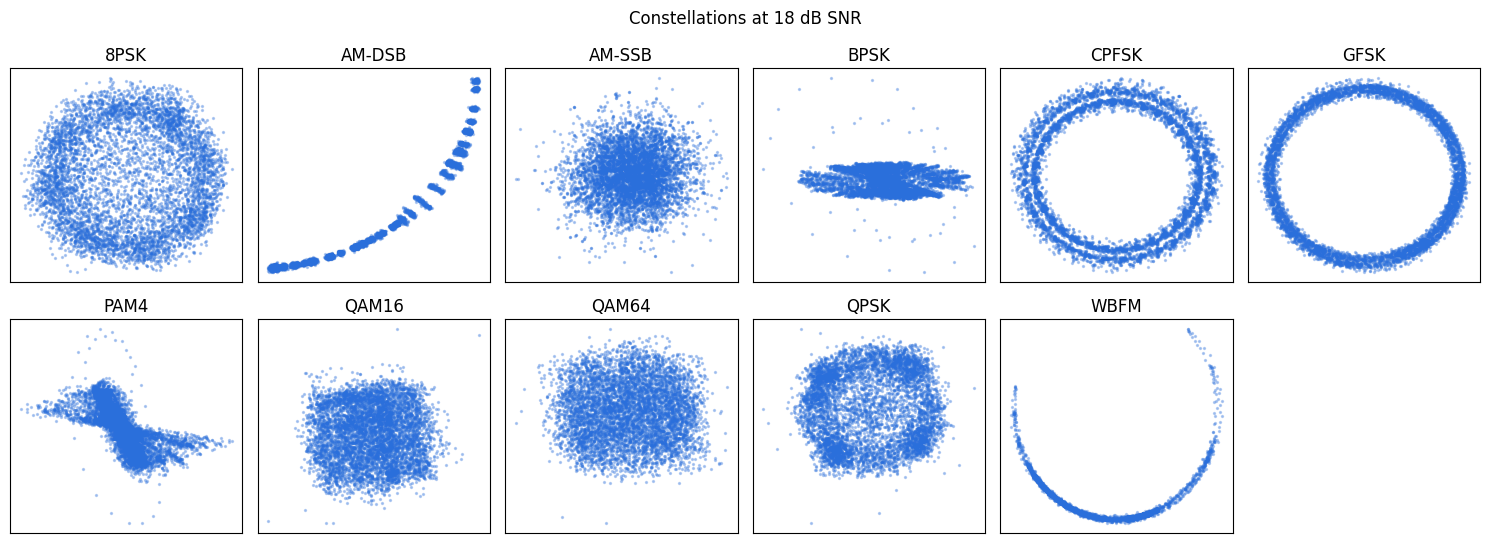

In [4]:
fig, axes = plt.subplots(2, 6, figsize=(15, 5.5))
for ax, m in zip(axes.flat, mods):
    x = data[(m, 18)][:50]  # 50 examples overlaid
    ax.scatter(x[:, 0].ravel(), x[:, 1].ravel(), s=2, alpha=0.3, color="#2a6fdb")
    ax.set_title(m)
    ax.set_xticks([]); ax.set_yticks([])
axes.flat[-1].axis("off")
fig.suptitle("Constellations at 18 dB SNR")
plt.tight_layout()

Same signal (QPSK) as I/Q over time at different SNRs. At -20 dB it should look like pure noise.

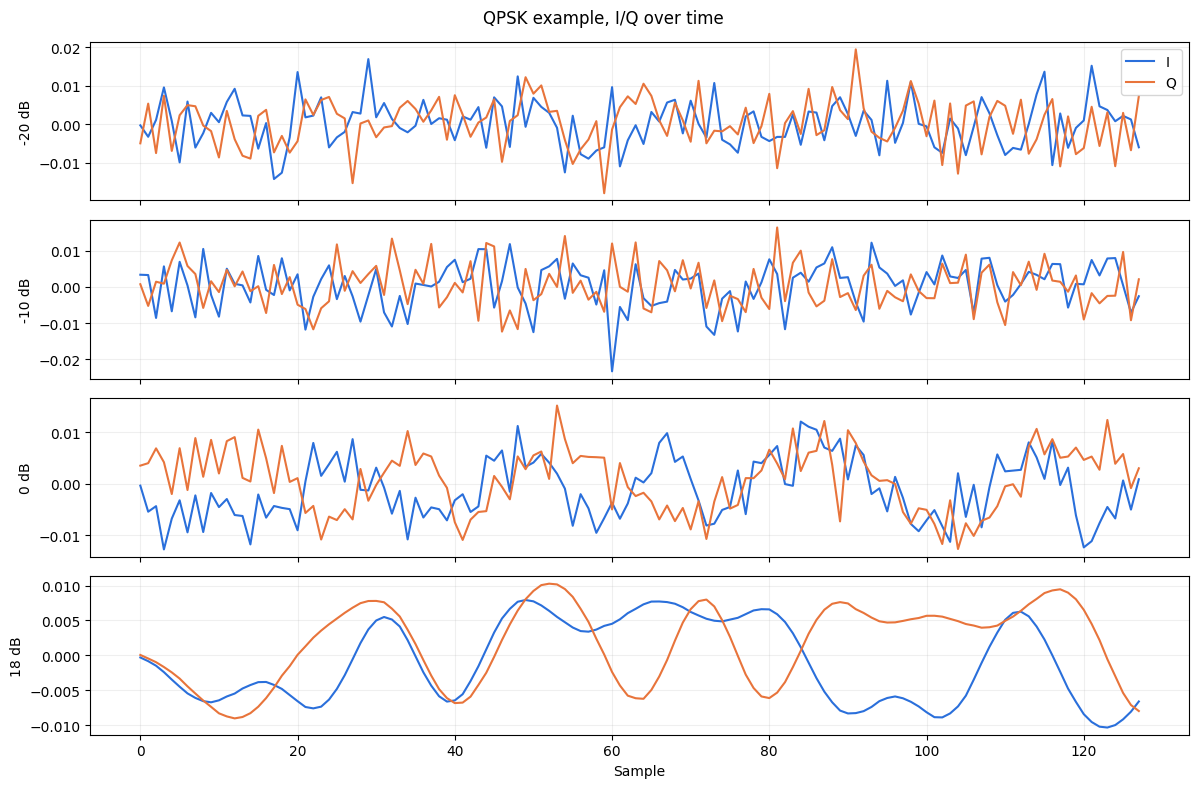

In [5]:
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
for ax, s in zip(axes, [-20, -10, 0, 18]):
    x = data[("QPSK", s)][0]
    ax.plot(x[0], label="I", color="#2a6fdb", lw=1.5)
    ax.plot(x[1], label="Q", color="#e8743b", lw=1.5)
    ax.set_ylabel(f"{s} dB")
    ax.grid(alpha=0.2)
axes[0].legend(loc="upper right")
axes[-1].set_xlabel("Sample")
fig.suptitle("QPSK example, I/Q over time")
plt.tight_layout()

Frequency content: average power spectrum per modulation at 18 dB.

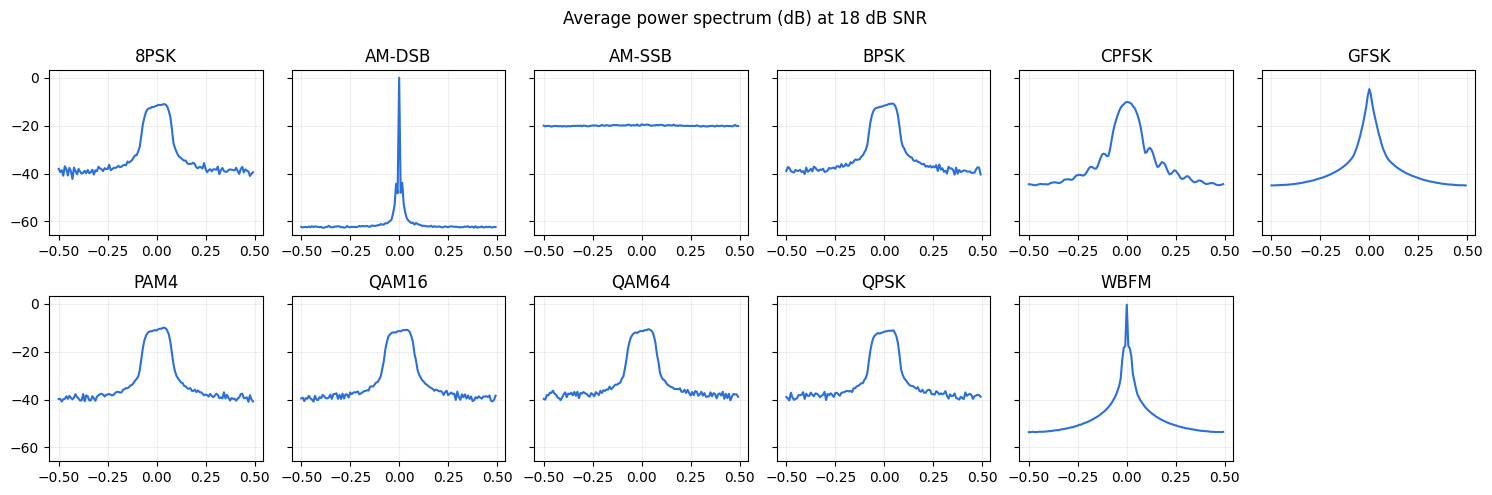

In [6]:
fig, axes = plt.subplots(2, 6, figsize=(15, 5), sharey=True)
freqs = np.fft.fftshift(np.fft.fftfreq(128))
for ax, m in zip(axes.flat, mods):
    x = data[(m, 18)]
    z = x[:, 0] + 1j * x[:, 1]
    psd = np.mean(np.abs(np.fft.fftshift(np.fft.fft(z, axis=1), axes=1)) ** 2, axis=0)
    ax.plot(freqs, 10 * np.log10(psd), color="#2a6fdb", lw=1.5)
    ax.set_title(m)
    ax.grid(alpha=0.2)
axes.flat[-1].axis("off")
fig.suptitle("Average power spectrum (dB) at 18 dB SNR")
plt.tight_layout()

## 3. Power per example
**Important for detection:** every example is normalized to roughly the same total power, whatever its SNR. So you can't detect a signal by loudness alone, and any noise-only examples you generate must be scaled to match.

Power min / median / max: 6.103645e-05 7.5120086e-05 0.0006465912
All-zero examples: 0


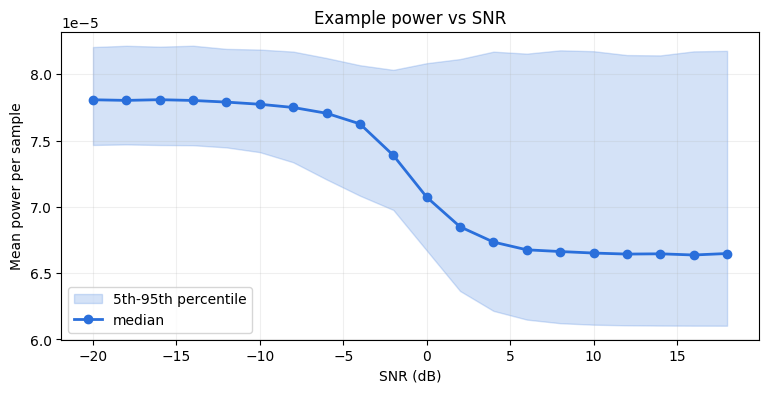

In [7]:
power = (X ** 2).sum(axis=1).mean(axis=1)   # mean |z|^2 per example

med = [np.median(power[y_snr == s]) for s in snrs]
lo  = [np.percentile(power[y_snr == s], 5) for s in snrs]
hi  = [np.percentile(power[y_snr == s], 95) for s in snrs]

fig, ax = plt.subplots(figsize=(9, 4))
ax.fill_between(snrs, lo, hi, color="#2a6fdb", alpha=0.2, label="5th-95th percentile")
ax.plot(snrs, med, color="#2a6fdb", lw=2, marker="o", label="median")
ax.set_xlabel("SNR (dB)"); ax.set_ylabel("Mean power per sample")
ax.set_title("Example power vs SNR")
ax.grid(alpha=0.2); ax.legend()

print("Power min / median / max:", power.min(), np.median(power), power.max())
print("All-zero examples:", (power == 0).sum())

Outliers: the highest-power examples, which are worth a look before deciding whether to drop them.

In [8]:
idx = np.argsort(power)[::-1][:10]
for i in idx:
    print(f"{y_mod[i]:7s} {y_snr[i]:4d} dB  power={power[i]:.2e}  ({power[i]/np.median(power):.1f}x median)")
print("Examples > 3x median power:", (power > 3 * np.median(power)).sum())

QAM16     14 dB  power=6.47e-04  (8.6x median)
QAM16     16 dB  power=5.78e-04  (7.7x median)
BPSK      18 dB  power=5.33e-04  (7.1x median)
PAM4      16 dB  power=5.26e-04  (7.0x median)
PAM4      14 dB  power=5.20e-04  (6.9x median)
QAM64     14 dB  power=5.19e-04  (6.9x median)
QAM64      6 dB  power=5.12e-04  (6.8x median)
QAM16     10 dB  power=4.98e-04  (6.6x median)
8PSK      16 dB  power=4.91e-04  (6.5x median)
PAM4      18 dB  power=4.80e-04  (6.4x median)
Examples > 3x median power: 73


## 4. DC offset
A non-zero mean in I or Q is a common hardware impairment worth removing.

In [9]:
dc = X.mean(axis=2)   # (N, 2)
print("Mean DC offset  I: %.2e  Q: %.2e" % tuple(dc.mean(axis=0)))
print("Max |DC| per example  I: %.2e  Q: %.2e" % tuple(np.abs(dc).max(axis=0)))

Mean DC offset  I: 6.98e-05  Q: -6.17e-04
Max |DC| per example  I: 7.81e-03  Q: 7.81e-03
